In [1]:
from pathlib import Path
import joblib

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import ast

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import RobustScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.utils.validation import check_is_fitted

from sklearn.pipeline import Pipeline

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold, RepeatedStratifiedKFold, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

from sklearn.linear_model import LogisticRegression


from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    average_precision_score,
    PrecisionRecallDisplay,
    f1_score
)

from sklearn.preprocessing import MultiLabelBinarizer, label_binarize, OneHotEncoder
from collections import Counter
from sklearn.dummy import DummyClassifier

from collections import defaultdict

In [2]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted')

In [3]:
data_dir = Path('../../results')

#Load dfs
train = pd.read_csv(data_dir / 'train_clean.csv')
test = pd.read_csv(data_dir / 'test_clean.csv')

In [4]:
# Create copies of the dataframes to manipulate
df_train = train.copy()
df_test = test.copy()

In [5]:
# Define target variables

y_train_rating = df_train['rating']
y_test_rating = df_test['rating']

y_train_titleType = df_train['titleType']
y_test_titleType = df_test['titleType']

In [6]:
def check_columns(train_df, test_df):
    train_cols = set(train_df.columns)
    test_cols = set(test_df.columns)
    if train_cols == test_cols:
        print("Train and test columns match.")
    else:
        print("Train and test columns DO NOT match.")
        print("Only in train:", train_cols - test_cols)
        print("Only in test:", test_cols - train_cols)

check_columns(df_train, df_test)


Train and test columns match.


In [7]:
df_train.columns

Index(['originalTitle', 'rating', 'startYear', 'runtimeMinutes', 'numVotes',
       'totalImages', 'totalCredits', 'titleType', 'canHaveEpisodes',
       'numRegions', 'countryOfOrigin', 'genres', 'companiesNumber',
       'averageRating', 'regions', 'externalLinks', 'writerCredits',
       'numGenres', 'criticReviewsRatio', 'hasAwards',
       'hasAwardsOrNominations', 'hasVideos', 'hasCriticsReviews',
       'hasUserReviews', 'moreDirectorsCredits', 'hasQuotes',
       'moreCountriesOfOrigin'],
      dtype='object')

In [8]:
# drop target variables
df_train.drop(columns=['rating', 'averageRating'], inplace=True) 
df_test.drop(columns=['rating', 'averageRating'], inplace=True)

check_columns(df_train, df_test)
df_train.columns

Train and test columns match.


Index(['originalTitle', 'startYear', 'runtimeMinutes', 'numVotes',
       'totalImages', 'totalCredits', 'titleType', 'canHaveEpisodes',
       'numRegions', 'countryOfOrigin', 'genres', 'companiesNumber', 'regions',
       'externalLinks', 'writerCredits', 'numGenres', 'criticReviewsRatio',
       'hasAwards', 'hasAwardsOrNominations', 'hasVideos', 'hasCriticsReviews',
       'hasUserReviews', 'moreDirectorsCredits', 'hasQuotes',
       'moreCountriesOfOrigin'],
      dtype='object')

In [9]:
df_train.T

,0,1,2,3,4,5,6,7,8,9,...,104654,104655,104656,104657,104658,104659,104660,104661,104662,104663
originalTitle,Kaala Sona,Deu Veado na Cabeça,Who Gets to Keep Togepy!?,Momma Croc,Mon ami le traître,Vio-grafia,Fran's Gotta Have It,Vet Safari,Episode #9.1,Le château perdu,...,Episode #1.4,Infest Wisely,Andante,Lysande utsikter,Drottningen,The Real Housewives of Grenada,13 Sins,Skinny Fat Girl,The Third Match: On The Edge,Trail of Carnage
startYear,1975,1982,1998,2011,1988,1975,1997,2006,2018,1973,...,2023,2007,2017,1993,2003,2024,2014,2016,2010,2014
runtimeMinutes,4.927254,4.51086,3.135494,3.433987,4.795791,4.584967,3.433987,3.401197,3.433987,4.477337,...,3.7612,4.465908,4.110874,3.713572,3.433987,3.433987,4.543295,2.564949,3.135494,3.806662
numVotes,4.543295,3.555348,6.270988,2.397895,5.26269,2.639057,5.849325,2.302585,2.197225,2.302585,...,2.890372,2.70805,5.620401,2.890372,2.302585,3.178054,10.590818,2.302585,3.78419,2.564949
totalImages,2.70805,0.693147,1.098612,0.0,0.693147,0.693147,1.386294,0.0,2.302585,0.0,...,0.693147,0.693147,2.484907,0.693147,0.693147,0.693147,4.276666,0.693147,1.098612,2.302585
totalCredits,4.49981,3.367296,3.713572,2.772589,4.043051,2.302585,4.304065,2.079442,4.927254,2.639057,...,2.564949,4.025352,2.772589,4.882802,3.044522,4.779123,5.638355,2.484907,2.564949,3.135494
titleType,movie,movie,tvEpisode,tvEpisode,movie,movie,tvEpisode,tvSeries,tvEpisode,tvMovie,...,tvEpisode,movie,tvSeries,tvEpisode,tvEpisode,tvEpisode,movie,short,tvEpisode,tvEpisode
canHaveEpisodes,False,False,False,False,False,False,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
numRegions,1.098612,0.693147,0.693147,0.0,2.397895,0.693147,0.693147,1.098612,2.079442,0.693147,...,2.079442,0.693147,0.693147,0.0,0.0,0.0,3.688879,0.693147,0.0,0.0
countryOfOrigin,['IN'],['BR'],['JP'],[],['FR'],['GR'],['US'],['GB'],[],['FR'],...,[],['CA'],['KR'],[],[],[],['US'],['US'],[],[]


In [10]:
df_train.describe()

,startYear,runtimeMinutes,numVotes,totalImages,totalCredits,numRegions,companiesNumber,externalLinks,writerCredits,numGenres,criticReviewsRatio
count,104664.000000,104664.000000,104664.000000,104664.000000,104664.000000,104664.000000,104664.000000,104664.000000,104664.000000,104664.000000,104664.000000
mean,1994.872401,3.696486,3.843363,1.154093,3.477648,0.921190,1.327326,0.861136,0.839394,1.967181,0.143157
std,24.929007,0.754579,1.665577,1.145585,1.097801,0.807096,0.934130,1.074684,0.618012,0.872111,0.295923
min,1878.000000,0.000000,1.791759,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1981.000000,3.433987,2.564949,0.693147,2.833213,0.693147,0.693147,0.000000,0.000000,1.000000,0.000000
50%,1999.000000,3.433987,3.367296,0.693147,3.555348,0.693147,1.098612,0.693147,0.693147,2.000000,0.000000
75%,2015.000000,4.356709,4.682131,1.609438,4.174387,1.386294,1.791759,1.386294,1.386294,3.000000,0.000000
max,2024.000000,6.573680,14.896614,9.932415,10.135353,4.330733,6.393591,6.569481,3.737670,3.000000,1.000000


In [11]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104664 entries, 0 to 104663
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   originalTitle           104664 non-null  object 
 1   startYear               104664 non-null  int64  
 2   runtimeMinutes          104664 non-null  float64
 3   numVotes                104664 non-null  float64
 4   totalImages             104664 non-null  float64
 5   totalCredits            104664 non-null  float64
 6   titleType               104664 non-null  object 
 7   canHaveEpisodes         104664 non-null  bool   
 8   numRegions              104664 non-null  float64
 9   countryOfOrigin         104664 non-null  object 
 10  genres                  104664 non-null  object 
 11  companiesNumber         104664 non-null  float64
 12  regions                 104664 non-null  object 
 13  externalLinks           104664 non-null  float64
 14  writerCredits       

# Pre-processing

In [12]:
num_cols = df_train.dtypes[(df_train.dtypes == 'float64') | (df_train.dtypes == 'int64')].index
bool_cols = df_train.dtypes[df_train.dtypes == 'bool'].index
#cat_cols = df_train.dtypes[df_train.dtypes == 'object'].drop(['originalTitle','countryOfOrigin','genres','regions','rating']).index #drop the target var and lists
cat_cols = df_train.dtypes[df_train.dtypes == 'object'].drop(['originalTitle','countryOfOrigin','genres','regions']).index #drop the target var and lists

In [13]:
num_cols, bool_cols, cat_cols #NB: cat_cols only contains titleType, this is for rating as a target

(Index(['startYear', 'runtimeMinutes', 'numVotes', 'totalImages',
        'totalCredits', 'numRegions', 'companiesNumber', 'externalLinks',
        'writerCredits', 'numGenres', 'criticReviewsRatio'],
       dtype='object'),
 Index(['canHaveEpisodes', 'hasAwards', 'hasAwardsOrNominations', 'hasVideos',
        'hasCriticsReviews', 'hasUserReviews', 'moreDirectorsCredits',
        'hasQuotes', 'moreCountriesOfOrigin'],
       dtype='object'),
 Index(['titleType'], dtype='object'))

In [14]:
# Lists: countryOfOrigin, genres, regions	
df_train['countryOfOrigin'] = df_train['countryOfOrigin'].apply(ast.literal_eval)
df_train['genres'] = df_train['genres'].apply(ast.literal_eval)
df_train['regions'] = df_train['regions'].apply(ast.literal_eval)

df_test['countryOfOrigin'] = df_test['countryOfOrigin'].apply(ast.literal_eval)
df_test['genres'] = df_test['genres'].apply(ast.literal_eval)
df_test['regions'] = df_test['regions'].apply(ast.literal_eval)

In [15]:
all_countries = [country for countries in df_train['countryOfOrigin'] for country in countries]
country_counts = Counter(all_countries) #Counter: dictionary 'country':count

In [16]:
top_n_countries = 25
country_counts.most_common(top_n_countries)
#n.25: only 0.53% of the dataset 

[('US', 33602),
 ('GB', 8068),
 ('FR', 3869),
 ('JP', 3861),
 ('CA', 2935),
 ('IN', 2909),
 ('DE', 2379),
 ('IT', 2042),
 ('AU', 1486),
 ('ES', 1484),
 ('SUHH', 1176),
 ('XWG', 1152),
 ('MX', 1132),
 ('TR', 890),
 ('SE', 833),
 ('BR', 777),
 ('NL', 731),
 ('KR', 703),
 ('HK', 649),
 ('AR', 630),
 ('DK', 599),
 ('GR', 580),
 ('RU', 572),
 ('PL', 551),
 ('FI', 549)]

In [17]:
def clean_geo(geo, top_geo):
    """    Clean geographical data by replacing less common entries with 'Other'."""
    return [c if c in top_geo else "Other" for c in geo]

In [18]:
top_countries = set([country for country, _ in country_counts.most_common(top_n_countries)]) 

df_train['country_cleaned'] = df_train['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)
df_test['country_cleaned'] = df_test['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)

In [19]:
df_train['country_cleaned'].value_counts()

country_cleaned
[US]                          31369
[]                            27961
[GB]                           7070
[Other]                        6860
[JP]                           3594
                              ...  
[ES, AR, FR, DE]                  1
[US, Other, TR]                   1
[FR, GB, CA]                      1
[US, Other, CA, Other, ES]        1
[DK, DE]                          1
Name: count, Length: 1150, dtype: int64

In [20]:
all_regions = [region for regions in df_train['regions'] for region in regions]
region_counts = Counter(all_regions) #Counter: dictionary 'country':count

In [21]:
top_n_regions = 25
region_counts.most_common(top_n_regions)

[('US', 41593),
 ('GB', 18717),
 ('FR', 16163),
 ('JP', 15443),
 ('DE', 14736),
 ('ES', 14077),
 ('IT', 13777),
 ('IN', 11536),
 ('PT', 10204),
 ('CA', 9739),
 ('XWW', 8456),
 ('BR', 7720),
 ('AU', 6427),
 ('PL', 6354),
 ('HU', 5683),
 ('RU', 5672),
 ('GR', 5588),
 ('SE', 5402),
 ('MX', 4857),
 ('FI', 4844),
 ('SUHH', 4135),
 ('XWG', 4046),
 ('DK', 3628),
 ('TR', 3561),
 ('AR', 3298)]

In [22]:
top_regions = set([region for region, _ in region_counts.most_common(top_n_regions)])

df_train['region_cleaned'] = df_train['regions'].apply(clean_geo, top_geo=top_regions)
df_test['region_cleaned'] = df_test['regions'].apply(clean_geo, top_geo=top_regions)

In [23]:
df_train['region_cleaned'].value_counts()

region_cleaned
[]                                                                                                                                                                                                               24355
[US]                                                                                                                                                                                                             21945
[PT, IN, FR, IT, DE, JP, ES]                                                                                                                                                                                      5677
[GB]                                                                                                                                                                                                              4777
[Other]                                                                                                                      

In [24]:
# Custom transformer for MultiLabelBinarizer
class MultiLabelBinarizerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.mlb = MultiLabelBinarizer()

    def fit(self, X, y=None):
        self.mlb.fit(X)
        return self
    
    def transform(self, X):
        return self.mlb.transform(X)
    
    def get_feature_names_out(self, input_features=None):
        """Return feature names for output features"""
        check_is_fitted(self.mlb)
        return np.array([f"mlb__{label}" for label in self.mlb.classes_])

In [25]:
def build_preprocessor(num_cols, bool_cols, cat_cols):
    return ColumnTransformer(
        transformers=[
            ('num', PowerTransformer(), num_cols),
            ('bool', 'passthrough', bool_cols),
            ('cat', OneHotEncoder(), cat_cols),  # No need for drop='first': will handle multicollinearity w/ Logistic Regression model (default L2 penalty)
            ('countries', MultiLabelBinarizerTransformer(), 'country_cleaned'),
            ('genres', MultiLabelBinarizerTransformer(), 'genres'),
            ('regions', MultiLabelBinarizerTransformer(), 'region_cleaned')
        ]
    )

# Rating

Let's try one model w/ the default parameters and one using GridSearch.

In [26]:
pipeline = Pipeline([
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', LogisticRegression(random_state=42, max_iter=1000))
    ], verbose=True)


In [209]:
# DEFAULT PARAMS
baseline_LR = pipeline.fit(df_train, y_train_rating)
test_preds_rating = baseline_LR.predict(df_test)
print(classification_report(y_test_rating, test_preds_rating, digits=3))

[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   1.3s
[Pipeline] ............... (step 2 of 2) Processing clf, total=  14.1s


c:\Users\camim\anaconda3\envs\dm2_project\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

      (0, 1]      0.000     0.000     0.000        22
      (1, 2]      0.000     0.000     0.000       133
      (2, 3]      0.750     0.008     0.016       374
      (3, 4]      0.318     0.020     0.038      1035
      (4, 5]      0.328     0.047     0.082      2750
      (5, 6]      0.327     0.248     0.282      6270
      (6, 7]      0.341     0.374     0.357     11750
      (7, 8]      0.428     0.749     0.545     14613
      (8, 9]      0.310     0.048     0.083      6591
     (9, 10]      0.225     0.022     0.040      1319

    accuracy                          0.388     44857
   macro avg      0.303     0.152     0.144     44857
weighted avg      0.360     0.388     0.330     44857



c:\Users\camim\anaconda3\envs\dm2_project\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\camim\anaconda3\envs\dm2_project\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


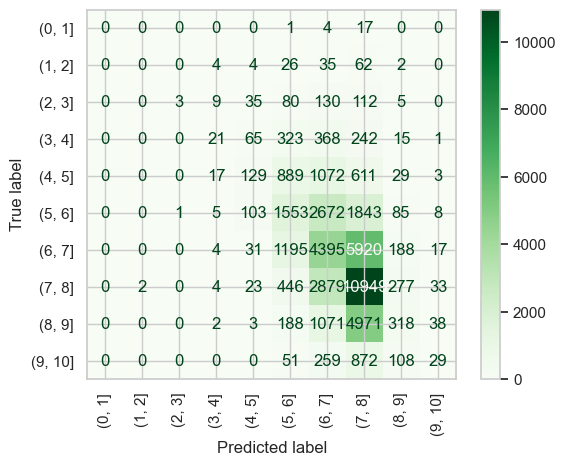

In [210]:
ConfusionMatrixDisplay.from_predictions(y_pred=test_preds_rating, y_true=y_test_rating,
                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()

Now, hyperparameter tuning.

In [71]:
#all possibile parameter combinations for Logistic Regression; usual values for C

param_grid = [
    # L2 regularization with multiple solvers
    {
        'clf__penalty': ['l2'],
        'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'clf__solver': ['lbfgs', 'sag', 'saga', 'newton-cholesky','newton-cg', 'liblinear']
    },
    # L1 regularization (only saga and liblinear)
    {
        'clf__penalty': ['l1'],
        'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'clf__solver': ['saga', 'liblinear']
    },
    # ElasticNet (only saga)
    {
        'clf__penalty': ['elasticnet'],
        'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'clf__solver': ['saga'],
        'clf__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
    }
]

In [72]:
grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(df_train, y_train_rating)

print(f"Best score: {grid_search.best_score_:.3f}; vs train score: {grid_search.best_estimator_.score(df_train, y_train_rating):.3f}")
print(f"Best parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 78 candidates, totalling 390 fits
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   2.2s
[Pipeline] ............... (step 2 of 2) Processing clf, total=  58.4s
Best score: 0.146; vs train score: 0.389
Best parameters: {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'newton-cholesky'}


In [74]:
"""
best_LR_model_rating = grid_search.best_estimator_
joblib.dump(best_LR_model_rating, data_dir/"best_LR_model_rating.pkl")
"""

['..\\..\\results\\best_LR_model_rating.pkl']

(modified MultiLabelBinarizerTransformer to get the features out; I'll just manually save the best parameters to avoid rerunning the grid search)

In [211]:
best_params_rating = {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'newton-cholesky'}
pipeline.set_params(**best_params_rating)
best_LR_model_rating = pipeline.fit(df_train, y_train_rating)

[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   1.8s
[Pipeline] ............... (step 2 of 2) Processing clf, total=  48.6s


c:\Users\camim\anaconda3\envs\dm2_project\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\camim\anaconda3\envs\dm2_project\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\camim\anaconda3\envs\dm2_project\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

              precision    recall  f1-score   support

      (0, 1]      0.000     0.000     0.000        22
      (1, 2]      0.000     0.000     0.000       133
      (2, 3]      0.750     0.008     0.016       374
      (3, 4]      0.319     0.021     0.040      1035
      (4, 5]      0.330     0.049     0.085      2750
      (5, 6]      0.328     0.249     0.283      6270
      (6, 7]      0.341     0.373     0.356     11750
      (7, 8]      0.428     0.749     0.544     14613
      (8, 9]      0.307     0.048     0.084      6591
     (9, 10]      0.252     0.025     0.046      1319

    accuracy                          0.388     44857
   macro avg      0.305     0.152     0.145     44857
weighted avg      0.361     0.388     0.330     44857



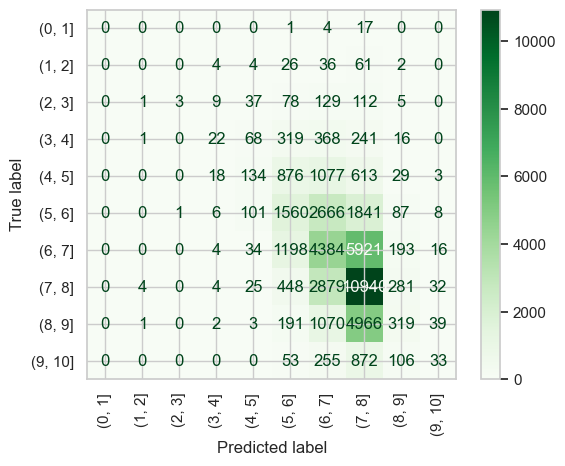

In [212]:
y_pred_rating = best_LR_model_rating.predict(df_test)
print(classification_report(y_test_rating, y_pred_rating, digits=3))

ConfusionMatrixDisplay.from_predictions(y_pred=y_pred_rating, y_true=y_test_rating,
                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()

In [213]:
print(f"Beta0: {best_LR_model_rating.named_steps['clf'].intercept_}\n")
print(f"Beta1: {best_LR_model_rating.named_steps['clf'].coef_}")

Beta0: [-5.7742313  -3.83262039 -1.27449207  0.39042058  2.58633768  2.77872276
  3.72699447  1.70870008  0.70145353 -1.01128534]

Beta1: [[ 0.28061375  0.17060636  0.37072933 ...  0.21028402 -0.01825005
  -0.79327004]
 [ 0.15286997 -0.18632692  0.52699862 ...  0.1477346  -0.92700835
   0.13438605]
 [ 0.03148104  0.06884402  0.1740781  ... -0.24425096  0.52729279
  -0.21780715]
 ...
 [-0.1282245   0.06391804  0.01689338 ...  0.09169096 -0.03695503
   0.47813672]
 [ 0.18990094  0.18383136 -0.09632781 ... -0.06788481  0.23124411
   0.1355542 ]
 [ 0.66770904  0.02789423 -0.16477072 ... -0.28397359 -0.3956059
  -0.30180574]]


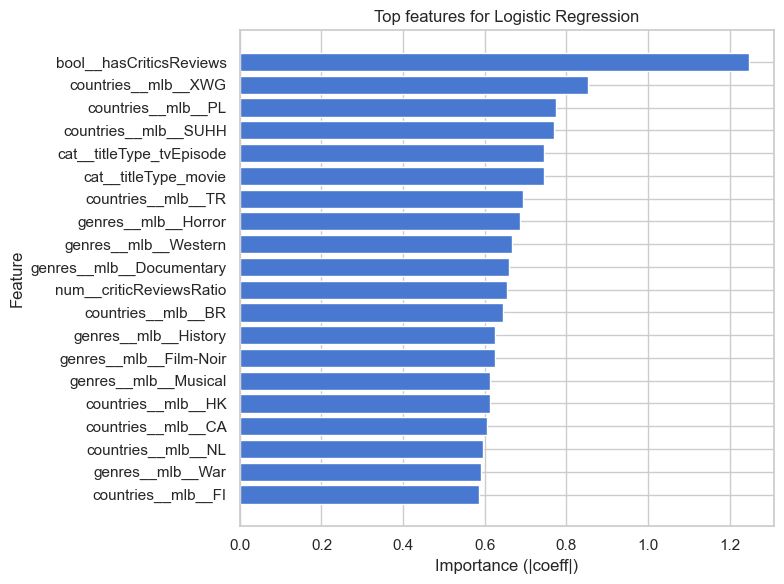

In [214]:
log_reg = best_LR_model_rating.named_steps["clf"]
preprocessor = best_LR_model_rating.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

coefs = log_reg.coef_
importance = np.mean(np.abs(coefs), axis=0)


# Sort in order of importance
sorted_idx = np.argsort(importance)[::-1]
top_n = 20  # n feats to show
top_features = feature_names[sorted_idx[:top_n]]
top_importances = importance[sorted_idx[:top_n]]

# Plot
plt.figure(figsize=(8, 6))
plt.barh(top_features[::-1], top_importances[::-1])
plt.xlabel("Importance (|coeff|)")
plt.ylabel("Feature")
plt.title("Top features for Logistic Regression")
plt.tight_layout()
plt.show()

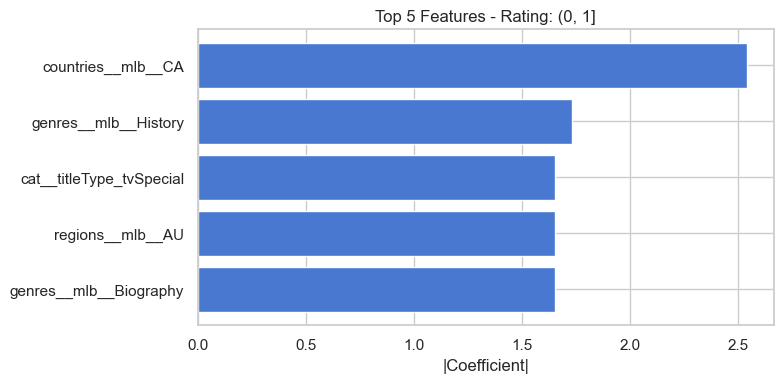

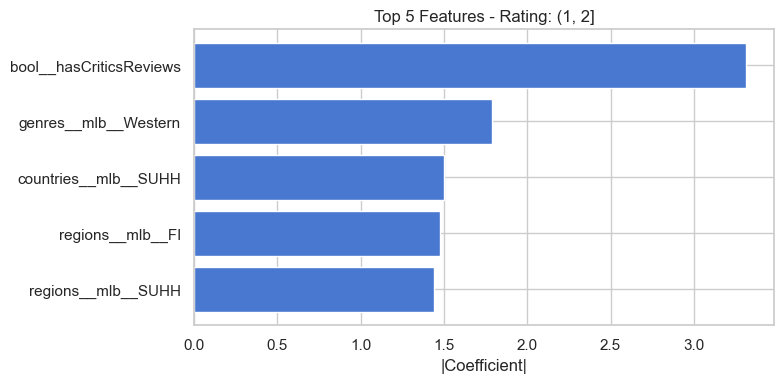

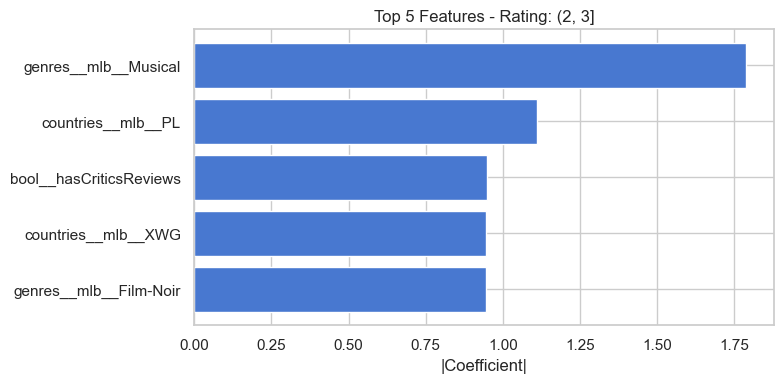

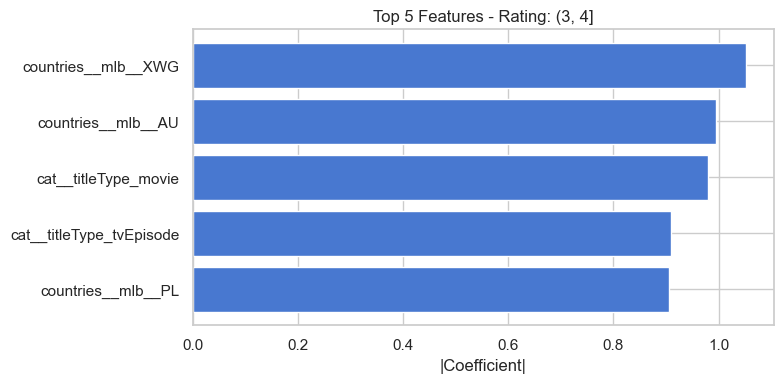

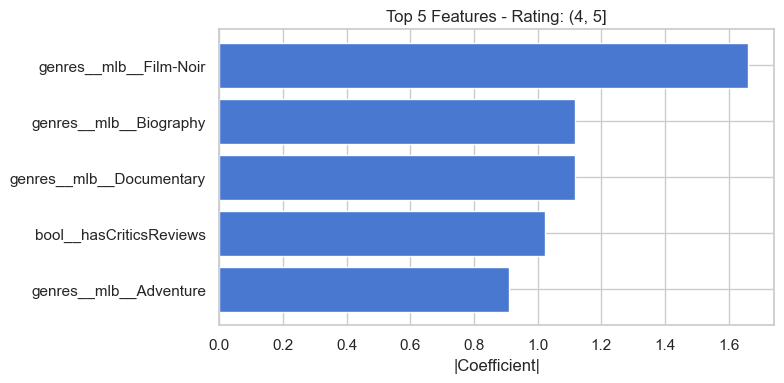

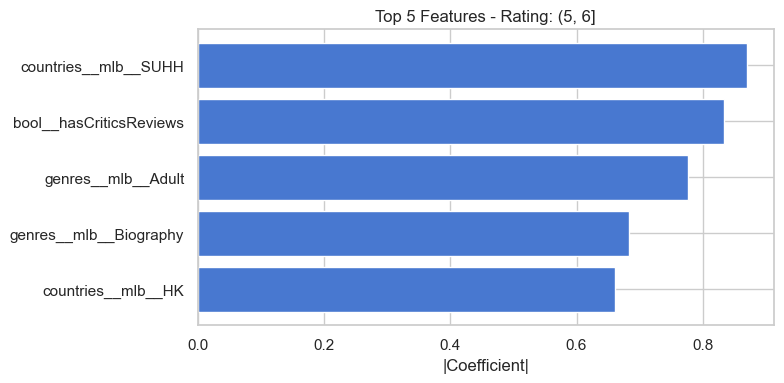

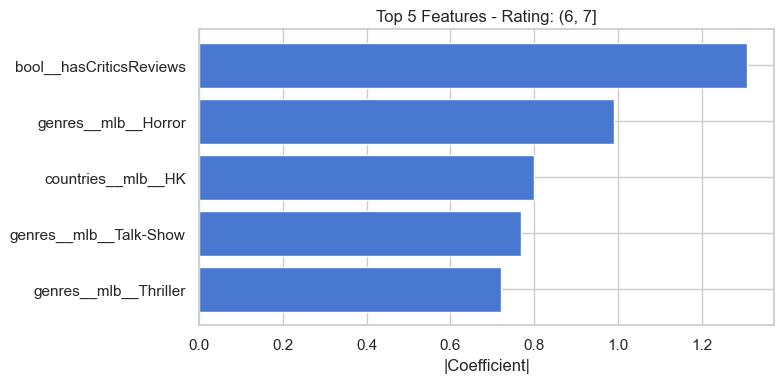

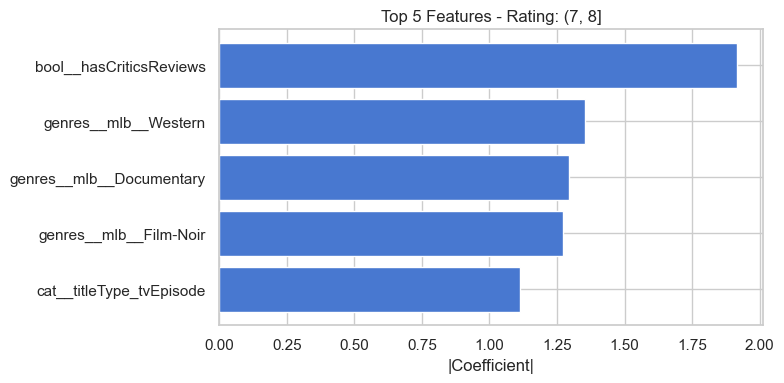

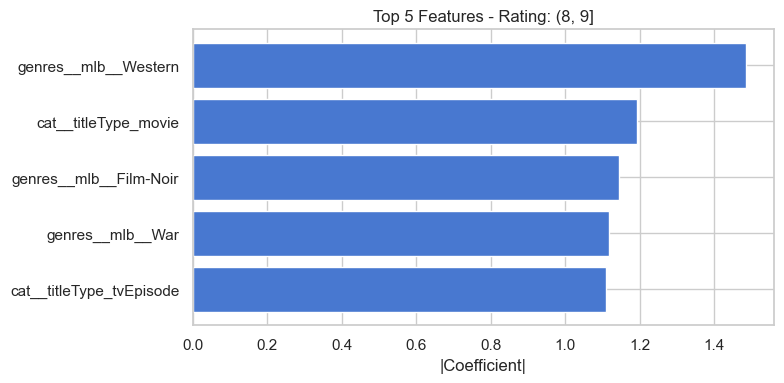

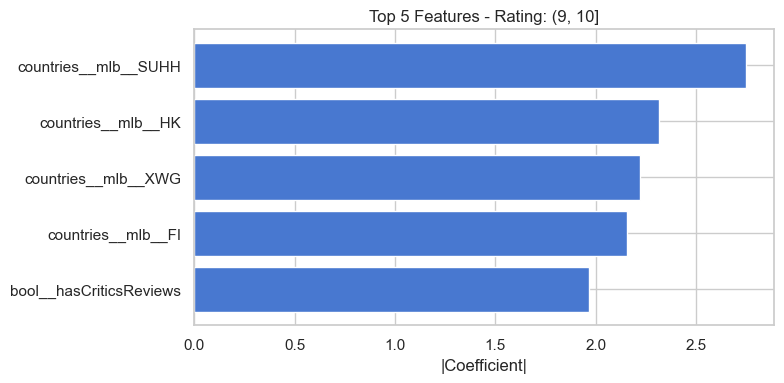

In [215]:
# top 5 features for each rating class
class_names = log_reg.classes_
for i, (class_name, coef) in enumerate(zip(class_names, coefs)):
    importance = np.abs(coef)
    sorted_idx = np.argsort(importance)[::-1][:5] 
    
    top_features = feature_names[sorted_idx]
    top_importance = importance[sorted_idx]
    
    plt.figure(figsize=(8, 4))
    plt.barh(range(len(top_features)), top_importance)
    plt.yticks(range(len(top_features)), top_features)
    plt.xlabel('|Coefficient|')
    plt.title(f'Top 5 Features - Rating: {class_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [216]:
print("------TOP 10 MOST IMPORTANT FEATURES BY RATING CLASS------")

for i, (class_name, coef) in enumerate(zip(class_names, coefs)):
    importance = np.abs(coef)  # Use absolute values for sorting
    sorted_idx = np.argsort(importance)[::-1][:10]  
    
    top_features = feature_names[sorted_idx]
    top_importance = coef[sorted_idx]  # But use actual coefficient values for display (pos or neg)

    print(f"\nRATING CLASS: {class_name}")
    print("-" * 50)
    
    for rank, (feature, imp) in enumerate(zip(top_features, top_importance), 1):
        print(f"{rank:2d}. {feature:<40} | Coef: {imp:.4f}")
    
    print()

------TOP 10 MOST IMPORTANT FEATURES BY RATING CLASS------

RATING CLASS: (0, 1]
--------------------------------------------------
 1. countries__mlb__CA                       | Coef: -2.5378
 2. genres__mlb__History                     | Coef: -1.7287
 3. cat__titleType_tvSpecial                 | Coef: 1.6525
 4. regions__mlb__AU                         | Coef: -1.6521
 5. genres__mlb__Biography                   | Coef: 1.6501
 6. regions__mlb__CA                         | Coef: 1.6468
 7. genres__mlb__Sport                       | Coef: -1.4769
 8. regions__mlb__PL                         | Coef: 1.4760
 9. genres__mlb__Sci-Fi                      | Coef: -1.4508
10. bool__hasQuotes                          | Coef: -1.4006


RATING CLASS: (1, 2]
--------------------------------------------------
 1. bool__hasCriticsReviews                  | Coef: 3.3153
 2. genres__mlb__Western                     | Coef: -1.7903
 3. countries__mlb__SUHH                     | Coef: 1.4975
 4. reg

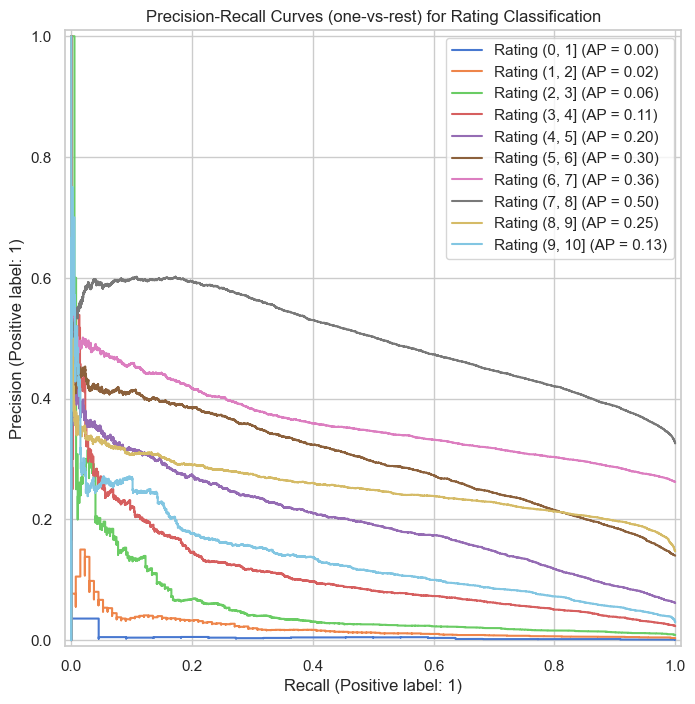

Macro average PR AUC: 0.193


In [217]:
# Get the classes and predictions from your trained rating model
class_labels = best_LR_model_rating.classes_
y_score = best_LR_model_rating.predict_proba(df_test)

# Binarize the test labels for multi-class PR curves
y_test_bin = label_binarize(y_test_rating, classes=class_labels)

# If binary classification, reshape
if y_test_bin.shape[1] == 1:
    y_test_bin = np.column_stack([1 - y_test_bin, y_test_bin])

plt.figure(figsize=(12, 8))
for i, class_label in enumerate(class_labels):
    PrecisionRecallDisplay.from_predictions(
        y_test_bin[:, i],
        y_score[:, i],
        name=f"Rating {class_label}",
        ax=plt.gca()
    )

plt.legend()
plt.title("Precision-Recall Curves (one-vs-rest) for Rating Classification")
plt.show()

print(f"Macro average PR AUC: {average_precision_score(y_test_bin, y_score, average='macro'):.3f}")

COMMENTS:
The overall performance isn't much higher than a dummy classifier's (macro f1: 0.145 vs 0.1). 
The model has somewhat generalized in the (5,8] interval. It most likely has to do with representation, as the performances peak for (7,8], the most popular class, with F1=0.544: the data distribution resembles a Gaussian distribution, therefore the lowest and highest classes are underrepresented. The center part of the distribution, although counting on a higher support, struggles with confusion, especially among adjacent classes. Indeed, (8,9] has a support slightly bigger than (5,6] in the training set, but has achieved poorer results bc it was confused with (7,8] most of the time.

Looking at the coefficients, the overall most important feature is hasCriticReviews: it is the 1st or 2nd biggest coef for all best performing classes, and for all of them it takes on a negative value - having critical reviews lowers the prob of a record of having an 'average' rating.

# TitleType

In [27]:
# Overwrite
df_train = train.copy()
df_test = test.copy()

In [28]:
df_train.columns

Index(['originalTitle', 'rating', 'startYear', 'runtimeMinutes', 'numVotes',
       'totalImages', 'totalCredits', 'titleType', 'canHaveEpisodes',
       'numRegions', 'countryOfOrigin', 'genres', 'companiesNumber',
       'averageRating', 'regions', 'externalLinks', 'writerCredits',
       'numGenres', 'criticReviewsRatio', 'hasAwards',
       'hasAwardsOrNominations', 'hasVideos', 'hasCriticsReviews',
       'hasUserReviews', 'moreDirectorsCredits', 'hasQuotes',
       'moreCountriesOfOrigin'],
      dtype='object')

In [29]:
# drop target variable and rating (we'll use averageRating)
df_train.drop(columns=['rating', 'titleType'], inplace=True) 
df_test.drop(columns=['rating', 'titleType'], inplace=True)

check_columns(df_train, df_test)
df_train.columns

Train and test columns match.


Index(['originalTitle', 'startYear', 'runtimeMinutes', 'numVotes',
       'totalImages', 'totalCredits', 'canHaveEpisodes', 'numRegions',
       'countryOfOrigin', 'genres', 'companiesNumber', 'averageRating',
       'regions', 'externalLinks', 'writerCredits', 'numGenres',
       'criticReviewsRatio', 'hasAwards', 'hasAwardsOrNominations',
       'hasVideos', 'hasCriticsReviews', 'hasUserReviews',
       'moreDirectorsCredits', 'hasQuotes', 'moreCountriesOfOrigin'],
      dtype='object')

In [30]:
# overwrite to make sure they're up to date

num_cols = df_train.dtypes[(df_train.dtypes == 'float64') | (df_train.dtypes == 'int64')].index
bool_cols = df_train.dtypes[df_train.dtypes == 'bool'].index
cat_cols = df_train.dtypes[df_train.dtypes == 'object'].drop(['originalTitle','countryOfOrigin','genres','regions']).index #drop the target var and lists

In [31]:
num_cols, bool_cols, cat_cols

(Index(['startYear', 'runtimeMinutes', 'numVotes', 'totalImages',
        'totalCredits', 'numRegions', 'companiesNumber', 'averageRating',
        'externalLinks', 'writerCredits', 'numGenres', 'criticReviewsRatio'],
       dtype='object'),
 Index(['canHaveEpisodes', 'hasAwards', 'hasAwardsOrNominations', 'hasVideos',
        'hasCriticsReviews', 'hasUserReviews', 'moreDirectorsCredits',
        'hasQuotes', 'moreCountriesOfOrigin'],
       dtype='object'),
 Index([], dtype='object'))

In [32]:
# Preprocess Lists: countryOfOrigin, genres, regions	
df_train['countryOfOrigin'] = df_train['countryOfOrigin'].apply(ast.literal_eval)
df_train['genres'] = df_train['genres'].apply(ast.literal_eval)
df_train['regions'] = df_train['regions'].apply(ast.literal_eval)

df_test['countryOfOrigin'] = df_test['countryOfOrigin'].apply(ast.literal_eval)
df_test['genres'] = df_test['genres'].apply(ast.literal_eval)
df_test['regions'] = df_test['regions'].apply(ast.literal_eval)

df_train['country_cleaned'] = df_train['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)
df_test['country_cleaned'] = df_test['countryOfOrigin'].apply(clean_geo, top_geo=top_countries)

df_train['region_cleaned'] = df_train['regions'].apply(clean_geo, top_geo=top_regions)
df_test['region_cleaned'] = df_test['regions'].apply(clean_geo, top_geo=top_regions)

In [33]:
# rebuild pipeline bc num_cols has changed

pipeline = Pipeline([
    ('preprocessor', build_preprocessor(num_cols, bool_cols, cat_cols)),
    ('clf', LogisticRegression(random_state=42, max_iter=1000))
], verbose=True)

In [150]:
# DEFAULT PARAMS
baseline_TT = pipeline.fit(df_train, y_train_titleType)
test_preds_TT = baseline_TT.predict(df_test)
print(classification_report(y_test_titleType, test_preds_TT, digits=3))

[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   1.5s
[Pipeline] ............... (step 2 of 2) Processing clf, total=   5.1s
              precision    recall  f1-score   support

       movie      0.863     0.947     0.903     11045
       short      0.923     0.938     0.930      4930
   tvEpisode      0.967     0.988     0.977     21234
tvMiniSeries      0.730     0.511     0.601       491
     tvMovie      0.588     0.307     0.404      1861
    tvSeries      0.919     0.967     0.943      2820
     tvShort      1.000     0.011     0.022        88
   tvSpecial      0.522     0.367     0.431       327
       video      0.611     0.408     0.489      1535
   videoGame      0.806     0.736     0.769       526

    accuracy                          0.908     44857
   macro avg      0.793     0.618     0.647     44857
weighted avg      0.898     0.908     0.899     44857



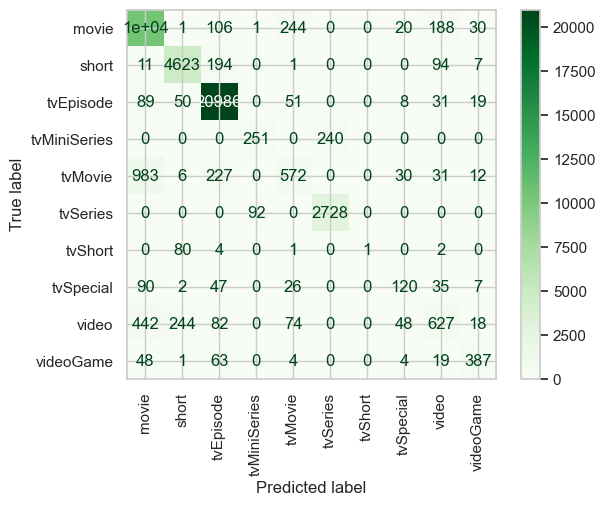

In [158]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted')
ConfusionMatrixDisplay.from_predictions(y_pred=test_preds_TT, y_true=y_test_titleType,
                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()

Now, hyperparameter tuning.

In [39]:
#all possibile parameter combinations for Logistic Regression; usual values for C

param_grid = [
    # L2 regularization with multiple solvers
    {
        'clf__penalty': ['l2'],
        'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'clf__solver': ['lbfgs', 'sag', 'saga', 'newton-cholesky','newton-cg', 'liblinear']
    },
    # L1 regularization (only saga and liblinear)
    {
        'clf__penalty': ['l1'],
        'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'clf__solver': ['saga', 'liblinear']
    },
    # ElasticNet (only saga)
    {
        'clf__penalty': ['elasticnet'],
        'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'clf__solver': ['saga'],
        'clf__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
    }
]

In [42]:
grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring=['accuracy', 'f1_macro', 'precision_macro', 'recall_macro'],
    refit='f1_macro',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(df_train, y_train_titleType)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score (macro F1): {grid_search.best_score_:.3f}; train score (accuracy!): {grid_search.best_estimator_.score(df_train, y_train_titleType):.3f}")

y_train_pred_ = grid_search.best_estimator_.predict(df_train)
train_f1 = f1_score(y_train_titleType, y_train_pred_, average='macro')
print(f"Train macro F1: {train_f1:.3f}")

Fitting 5 folds for each of 78 candidates, totalling 390 fits
[Pipeline] ...... (step 1 of 2) Processing preprocessor, total=   1.6s
[Pipeline] ............... (step 2 of 2) Processing clf, total=  26.7s
Best parameters: {'clf__C': 100, 'clf__penalty': 'l2', 'clf__solver': 'newton-cg'}
Best score (macro F1): 0.653; train score (accuracy!): 0.911
Train macro F1: 0.664


no overfitting (train macro f1: 0.664 vs validation 0.653)

In [ ]:
#best_LR_model_TT = grid_search.best_estimator_
#joblib.dump(best_LR_model_TT, data_dir/"best_LR_model_TT.pkl")

['..\\..\\results\\best_LR_model_TT.pkl']

In [34]:
best_LR_model_TT = joblib.load(data_dir/"best_LR_model_TT.pkl")

In [35]:
y_pred_tt = best_LR_model_TT.predict(df_test)
print(classification_report(y_test_titleType, y_pred_tt, digits=3))

              precision    recall  f1-score   support

       movie      0.864     0.945     0.902     11045
       short      0.924     0.937     0.931      4930
   tvEpisode      0.967     0.988     0.978     21234
tvMiniSeries      0.724     0.519     0.605       491
     tvMovie      0.582     0.312     0.406      1861
    tvSeries      0.920     0.966     0.943      2820
     tvShort      0.667     0.023     0.044        88
   tvSpecial      0.517     0.373     0.433       327
       video      0.606     0.412     0.491      1535
   videoGame      0.799     0.724     0.760       526

    accuracy                          0.908     44857
   macro avg      0.757     0.620     0.649     44857
weighted avg      0.897     0.908     0.899     44857



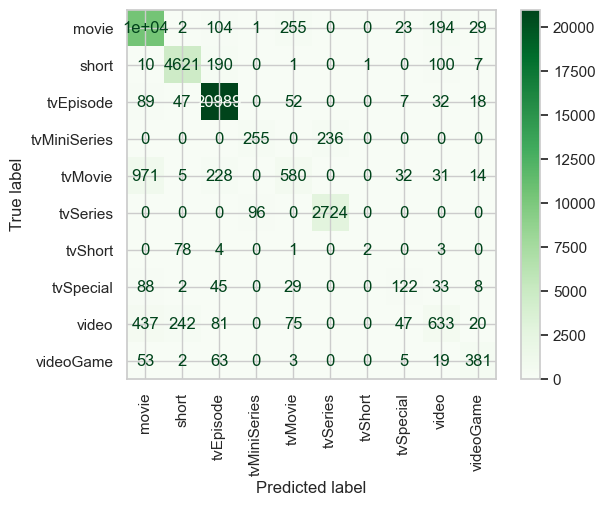

In [45]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted')
ConfusionMatrixDisplay.from_predictions(y_pred=y_pred_tt, y_true=y_test_titleType,
                                        xticks_rotation=90,
                                        cmap='Greens')
plt.show()

In [46]:
print(f"Beta0: {best_LR_model_TT.named_steps['clf'].intercept_}\n")
print(f"Beta1: {best_LR_model_TT.named_steps['clf'].coef_}")

Beta0: [-0.0350066  -0.49813767  8.48367613 -4.43321919  5.40231961 -3.71050314
 -3.7195342   0.08054945 -1.33637137 -0.23377303]

Beta1: [[-0.63128186  2.07549256 -0.17086022 ...  0.25107627  0.2756188
  -0.21117297]
 [-0.62038521 -1.81012826 -0.50040278 ... -0.09880604  0.22865479
  -0.01287596]
 [-0.06069334 -1.56628292  0.21506748 ... -0.95102574  0.9490508
  -0.1530445 ]
 ...
 [ 0.31865541  1.50769957  0.39843181 ...  0.15869038 -0.26410897
  -0.05188822]
 [ 0.62572426  0.63237296  0.11978028 ...  0.40617531 -0.82226601
   0.58027513]
 [ 0.35104821  0.02221633  0.21879836 ...  0.92386743 -1.7608364
   0.6220275 ]]


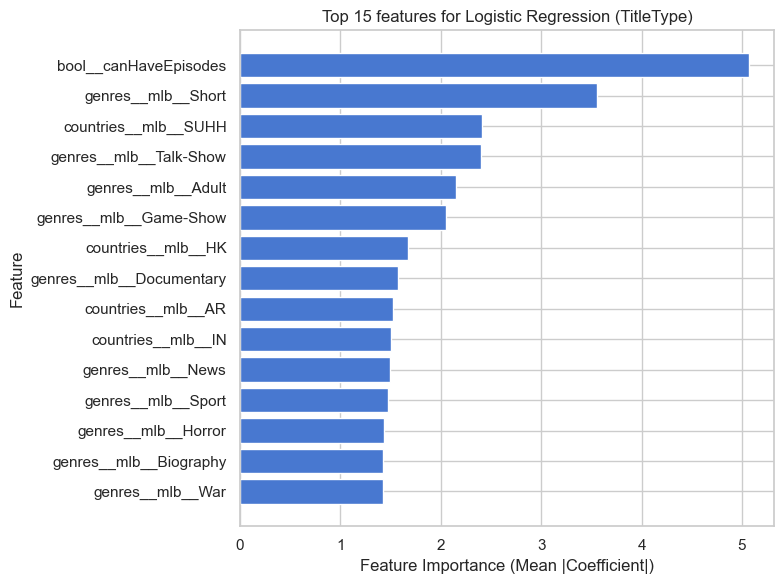

In [37]:
#overwrite
log_reg = best_LR_model_TT.named_steps["clf"]
preprocessor = best_LR_model_TT.named_steps["preprocessor"]
feature_names = preprocessor.get_feature_names_out()
coefs = log_reg.coef_
importance = np.mean(np.abs(coefs), axis=0)


# Sort in order of importance
sorted_idx = np.argsort(importance)[::-1]
top_n = 15  # n feats to show
top_features = feature_names[sorted_idx[:top_n]]
top_importances = importance[sorted_idx[:top_n]]

# Plot
plt.figure(figsize=(8, 6))
plt.barh(top_features[::-1], top_importances[::-1])
plt.xlabel("Feature Importance (Mean |Coefficient|)")
plt.ylabel("Feature")
plt.title("Top 15 features for Logistic Regression (TitleType)")
plt.tight_layout()
plt.show()

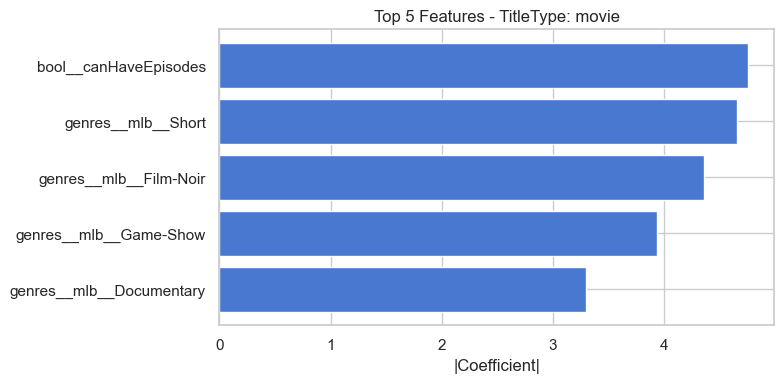

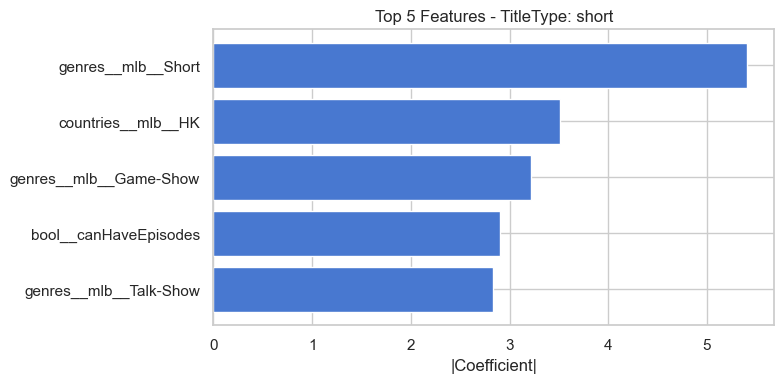

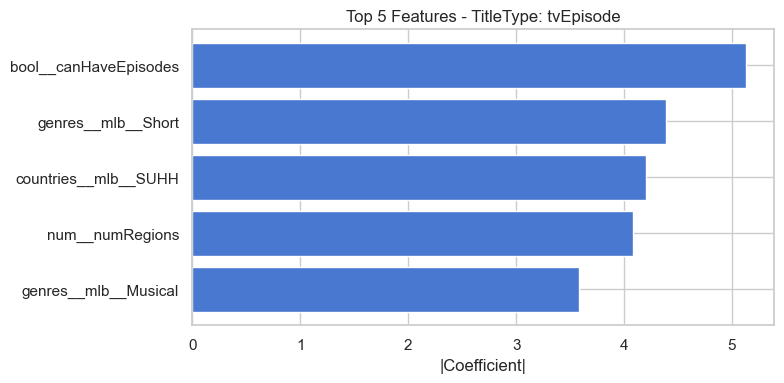

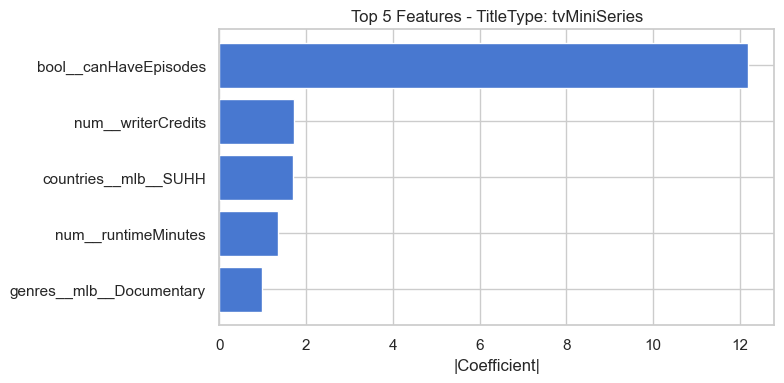

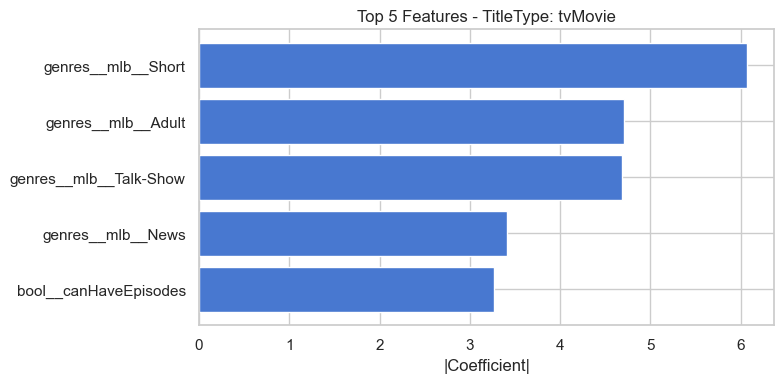

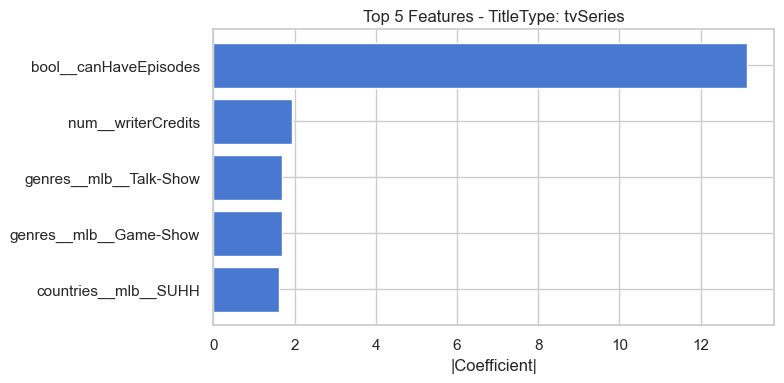

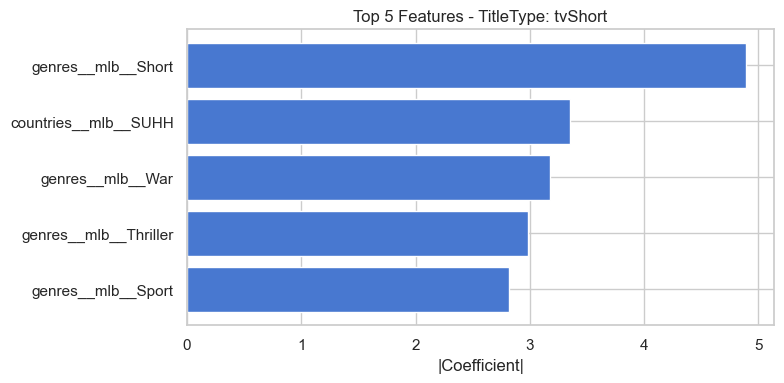

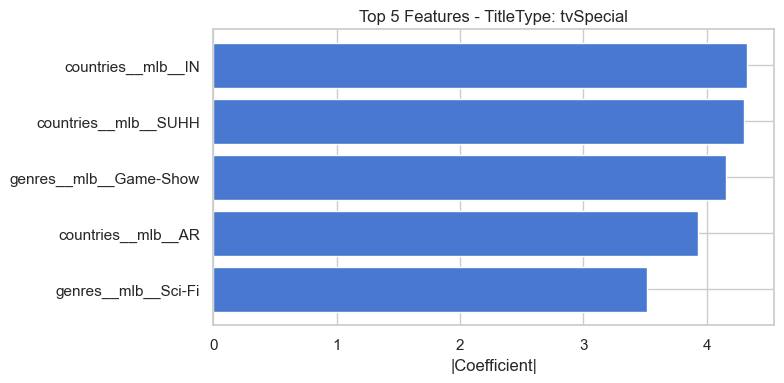

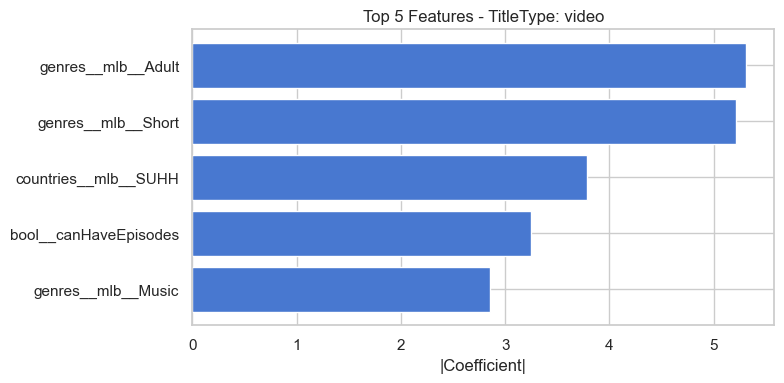

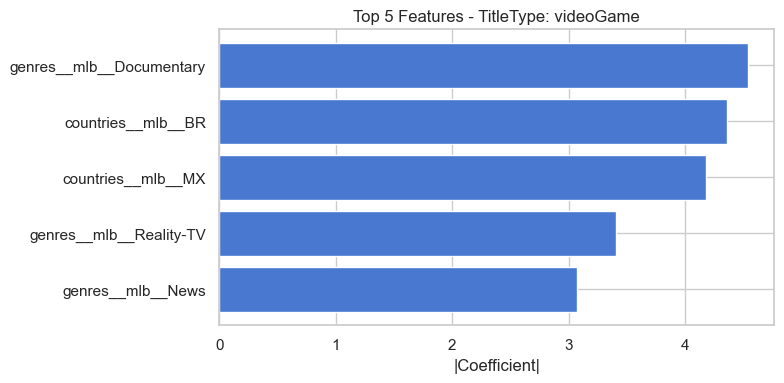

In [48]:
# top 5 features for each TitleType class
class_names = log_reg.classes_
for i, (class_name, coef) in enumerate(zip(class_names, coefs)):
    importance = np.abs(coef)
    sorted_idx = np.argsort(importance)[::-1][:5] 
    
    top_features = feature_names[sorted_idx]
    top_importance = importance[sorted_idx]
    
    plt.figure(figsize=(8, 4))
    plt.barh(range(len(top_features)), top_importance)
    plt.yticks(range(len(top_features)), top_features)
    plt.xlabel('|Coefficient|')
    plt.title(f'Top 5 Features - TitleType: {class_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [49]:
print("------TOP 10 MOST IMPORTANT FEATURES BY TitleType------")

for i, (class_name, coef) in enumerate(zip(class_names, coefs)):
    importance = np.abs(coef)  # Use absolute values for sorting
    sorted_idx = np.argsort(importance)[::-1][:10]  # Sort by absolute value to get most important
    
    top_features = feature_names[sorted_idx]
    top_importance = coef[sorted_idx]  # But use actual coefficient values for display
    
    print(f"\nTitleType: {class_name}")
    print("-" * 50)
    
    for rank, (feature, imp) in enumerate(zip(top_features, top_importance), 1):
        print(f"{rank:2d}. {feature:<40} | Coef: {imp:.4f}")
    
    print()

------TOP 10 MOST IMPORTANT FEATURES BY TitleType------

TitleType: movie
--------------------------------------------------
 1. bool__canHaveEpisodes                    | Coef: -4.7485
 2. genres__mlb__Short                       | Coef: -4.6497
 3. genres__mlb__Film-Noir                   | Coef: 4.3545
 4. genres__mlb__Game-Show                   | Coef: -3.9323
 5. genres__mlb__Documentary                 | Coef: 3.2925
 6. countries__mlb__IN                       | Coef: 3.0712
 7. countries__mlb__HK                       | Coef: 3.0604
 8. genres__mlb__Adult                       | Coef: 3.0551
 9. genres__mlb__Western                     | Coef: 2.7182
10. genres__mlb__Thriller                    | Coef: 2.6414


TitleType: short
--------------------------------------------------
 1. genres__mlb__Short                       | Coef: 5.4094
 2. countries__mlb__HK                       | Coef: 3.5142
 3. genres__mlb__Game-Show                   | Coef: -3.2169
 4. bool__canHaveEpis

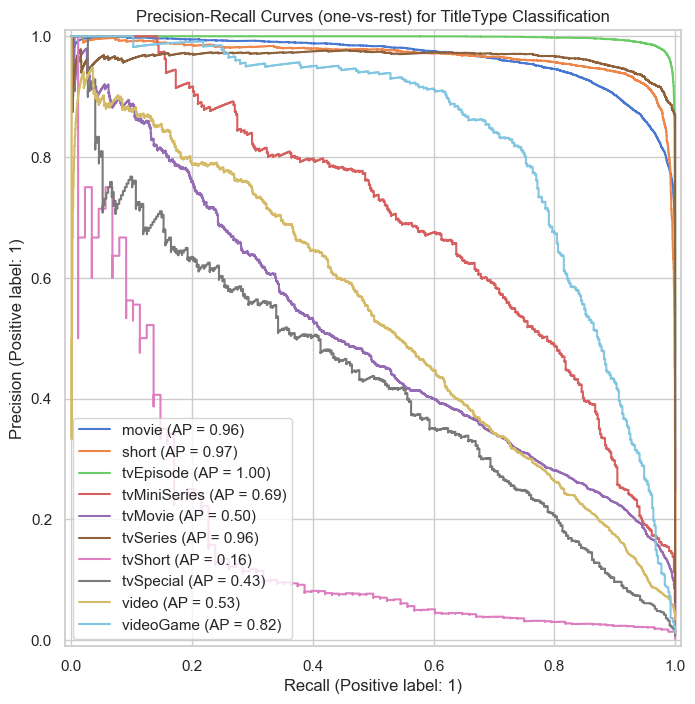

Macro average PR AUC: 0.704


In [50]:
# Get the classes and predictions from your trained model
class_labels = best_LR_model_TT.classes_
y_score = best_LR_model_TT.predict_proba(df_test)

# Binarize the test labels for multi-class PR curves
y_test_bin = label_binarize(y_test_titleType, classes=class_labels)

# If binary classification, reshape
if y_test_bin.shape[1] == 1:
    y_test_bin = np.column_stack([1 - y_test_bin, y_test_bin])

plt.figure(figsize=(12, 8))
for i, class_label in enumerate(class_labels):
    PrecisionRecallDisplay.from_predictions(
        y_test_bin[:, i],
        y_score[:, i],
        name=f"{class_label}",
        ax=plt.gca()
    )

plt.legend()
plt.title("Precision-Recall Curves (one-vs-rest) for TitleType Classification")
plt.show()

print(f"Macro average PR AUC: {average_precision_score(y_test_bin, y_score, average='macro'):.3f}")

COMMENTS

Significantly better macro F1 than the DummyClassifier (0.649 vs 0.10)

The model yields great accuracy (0.908) and good-enough macro F1 (0.649), in classic imbalanced-multiclass fashion.

The four most popular classes (tvEpisode, short, movie, tvSeries) achieve great results, w/ F1 > 0.9. All other classes (except tvShort) achieve results >0.4, which is significantly more than random chance. The confusion matrix shows reasonable confusion between tvMovie and movie, as well as between tvMiniSeries and tvSeries. Difference: tvMiniseries and tvSeries are only confused among each other, confusion for movie and tvmovie is more spread out.

Videogame, in spite of its low support, manages to achieve very good results (F1 0.760).

Overall, the most informative features are 
- canHaveEpisodes: very high positive values for tvSeries and tvMiniSeries and negative for all other classes; #1 also for movie 
- short: of course #1 for short and tvShort and #2 for video w/ positive value, high up w/ negative values for movie, tvEpisode, tvMovie.

→ better pr auc and curves than linear and non linear SVM


# Checking overfitting (rating)

Since during gridSearch we printed the train accuracy (thanks sklearn documentation), let's check our model's train macro F1 to check overfitting. Already done above for titleType.

In [28]:
best_LR_model_rating = joblib.load(data_dir / "best_LR_model_rating.pkl")
print("Best LR model for rating loaded successfully!")

Best LR model for rating loaded successfully!


In [29]:
y_pred_rating_train = best_LR_model_rating.predict(df_train)
print(classification_report(y_train_rating, y_pred_rating_train, digits=3))

              precision    recall  f1-score   support

      (0, 1]      0.500     0.015     0.029        66
      (1, 2]      0.455     0.015     0.028       341
      (2, 3]      0.333     0.005     0.010       808
      (3, 4]      0.351     0.022     0.042      2408
      (4, 5]      0.340     0.051     0.088      6336
      (5, 6]      0.331     0.246     0.283     15055
      (6, 7]      0.345     0.378     0.361     27276
      (7, 8]      0.426     0.749     0.543     33937
      (8, 9]      0.305     0.050     0.085     15475
     (9, 10]      0.230     0.026     0.046      2962

    accuracy                          0.389    104664
   macro avg      0.362     0.156     0.152    104664
weighted avg      0.360     0.389     0.331    104664



RATING
→ Train macro F1: 0.152
→ Validation macro F1: 0.146
→ Test macro F1: 0.145
no overfitting